<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Example

## Understanding Data

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
import pandas as pd

df_participants = pd.read_csv("data/week4/participants.csv") # to be used for feature engineering

df_sleep = pd.read_csv("data/week4/sleep.csv") # primary dataset for analysis

In [10]:
df_sleep.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             425 non-null    str    
 1   day                   425 non-null    str    
 2   sleep_begin           425 non-null    str    
 3   sleep_end             425 non-null    str    
 4   sleep_duration        425 non-null    float64
 5   sleep_awake_duration  9 non-null      float64
 6   sleep_rem_duration    7 non-null      float64
 7   sleep_light_duration  27 non-null     float64
 8   sleep_deep_duration   14 non-null     float64
 9   pulse_min             15 non-null     float64
 10  pulse_max             15 non-null     float64
 11  pulse_average         15 non-null     float64
dtypes: float64(8), str(4)
memory usage: 40.0 KB


In [11]:
df_sleep.nunique()

user_code                10
day                     154
sleep_begin             424
sleep_end               425
sleep_duration          334
sleep_awake_duration      6
sleep_rem_duration        5
sleep_light_duration     22
sleep_deep_duration      12
pulse_min                11
pulse_max                11
pulse_average            14
dtype: int64

Based on the github documentation, the sleep CSV contains daily aggregates of sleep metrics that describe the user, sleep beginning and end times, sleep duration, awake during during sleep times, REM duration during sleep times, light duration during sleep times, deep duration sleep times and a heart rate min/max/average over sleep time. Based on the unique values as well, this data is sampled from 154 days but from only 10 users which may limit generalizability. 

###
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?

In [12]:
# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {df_sleep.shape}")
print(f"Data Types:\n{df_sleep.dtypes}")
print(f"Missing Values:\n{df_sleep.isnull().sum()}")


Data Structure
---------------
Dimensions: (425, 12)
Data Types:
user_code                   str
day                         str
sleep_begin                 str
sleep_end                   str
sleep_duration          float64
sleep_awake_duration    float64
sleep_rem_duration      float64
sleep_light_duration    float64
sleep_deep_duration     float64
pulse_min               float64
pulse_max               float64
pulse_average           float64
dtype: object
Missing Values:
user_code                 0
day                       0
sleep_begin               0
sleep_end                 0
sleep_duration            0
sleep_awake_duration    416
sleep_rem_duration      418
sleep_light_duration    398
sleep_deep_duration     411
pulse_min               410
pulse_max               410
pulse_average           410
dtype: int64


##Interpretation

This indicates that there are 425 observations, which means 425 daily snapshots amongst 10 different users.

The data is split between categorical strings (user_code, day, sleep_begin, sleep_end) and numeric floats (sleep_duration, sleep_awale_duration, sleep_rem_duration, sleep_light duration, sleep_dep_duration, pulse_min, pulse_max, pulse_average). The days and times should be changed to datetime datatypes but everthing else has appropriate datatypes. 

The dataset is complete in user_code, day, sleep_begin, sleep_end, and sleep_duration but contains anywhere from 398 to 418 missing values for the rest, which is not enough to learn a signal or meaningfully impute values so these will have to be dropped. 

In [13]:
df_sleep['day'] = pd.to_datetime(df_sleep['day'])
df_sleep['sleep_begin'] = pd.to_datetime(df_sleep['sleep_begin'])
df_sleep['sleep_end'] = pd.to_datetime(df_sleep['sleep_end'])

df_sleep.head()

,user_code,day,sleep_begin,sleep_end,sleep_duration,sleep_awake_duration,sleep_rem_duration,sleep_light_duration,sleep_deep_duration,pulse_min,pulse_max,pulse_average
0,0d297d2410,2019-12-31,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0d297d2410,2020-01-01,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0d297d2410,2020-01-02,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0d297d2410,2020-01-03,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0d297d2410,2020-01-04,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0,NaN,NaN,21480.0,NaN,55.0,95.0,72.5


In [14]:
df_sleep.drop(columns=['sleep_awake_duration', 'sleep_rem_duration', 'sleep_awake_duration', 'sleep_deep_duration', 'sleep_light_duration', 'pulse_min', 'pulse_max', 'pulse_average'], inplace=True)
df_sleep.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_code       425 non-null    str           
 1   day             425 non-null    datetime64[us]
 2   sleep_begin     425 non-null    datetime64[us]
 3   sleep_end       425 non-null    datetime64[us]
 4   sleep_duration  425 non-null    float64       
dtypes: datetime64[us](3), float64(1), str(1)
memory usage: 16.7 KB


###
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [16]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df_sleep.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df_sleep[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df_sleep[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df_sleep[numeric_columns].skew())
print(df_sleep[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
      sleep_duration
mean    25699.731765
50%     26041.000000

Dispersion Measures:
     sleep_duration
std      7773.80547
min       930.00000
max     47460.00000

Distribution Measures:
------------------------
sleep_duration   -0.564909
dtype: float64
sleep_duration    0.827471
dtype: float64


In [17]:
df_sleep['sleep_duration'] = df_sleep['sleep_duration'] / 3600

In [18]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df_sleep.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df_sleep[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df_sleep[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df_sleep[numeric_columns].skew())
print(df_sleep[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
      sleep_duration
mean        7.138814
50%         7.233611

Dispersion Measures:
     sleep_duration
std        2.159390
min        0.258333
max       13.183333

Distribution Measures:
------------------------
sleep_duration   -0.564909
dtype: float64
sleep_duration    0.827471
dtype: float64


## Interpretation

#### Descriptive Statistics
The mean and median are relatively close for sleep_duration, indicating a roughly symmetric distribution. It is also clear here that this is reported in seconds, not hours as stated in documentation, so this is adjusted. After adjusting, the mean and median being around 7 hours makes sense.

#### Dispersion Measures
The standard deviation is around 2 hours, which is not alarming, but there does appear to be a wide range of values from 0.25 hours up to 13. 

#### Distribution Measures
With a skew of -0.5 there appears to be a slight to moderate left skew resulting in a tail as indicated by 0.8 Kurt score. 

###
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [19]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {df_sleep.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df_sleep.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                most_frequent_value
user_code                6be5033971
day             2020-05-15 00:00:00
sleep_begin     2020-05-19 00:03:00
sleep_end       2019-12-31 08:45:22
sleep_duration            10.166667


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.


All most frequent values are reasonable, with sleep tracking beginning commonly around 3 am and ending at 8:45 with a common duration og 10 hours.

###

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?


Before analyzing relationships, I want to add an indicator from participants that marks whether the person has a symptom_onset date to indicate whether they have had symptoms. This will be added to reveal differences in sleep patterns between those with and without a history of symptoms.

In [21]:
df_sleep.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_code       425 non-null    str           
 1   day             425 non-null    datetime64[us]
 2   sleep_begin     425 non-null    datetime64[us]
 3   sleep_end       425 non-null    datetime64[us]
 4   sleep_duration  425 non-null    float64       
dtypes: datetime64[us](3), float64(1), str(1)
memory usage: 16.7 KB


In [22]:
df_participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    str    
 1   gender          185 non-null    str    
 2   age_range       185 non-null    str    
 3   city            173 non-null    str    
 4   country         179 non-null    str    
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    str    
dtypes: float64(2), str(6)
memory usage: 11.7 KB


In [23]:
onset_flag = df_participants.set_index('user_code')['symptoms_onset'].notna().astype(int)

df_sleep['symptom_onset_flag'] = df_sleep['user_code'].map(onset_flag)

In [24]:
df_sleep['symptom_onset_flag'].value_counts()

symptom_onset_flag
1    252
0    173
Name: count, dtype: int64

In [29]:
df_sleep.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_code           425 non-null    str           
 1   day                 425 non-null    datetime64[us]
 2   sleep_begin         425 non-null    datetime64[us]
 3   sleep_end           425 non-null    datetime64[us]
 4   sleep_duration      425 non-null    float64       
 5   symptom_onset_flag  425 non-null    int64         
dtypes: datetime64[us](3), float64(1), int64(1), str(1)
memory usage: 20.1 KB



Variable Relationships
----------------------
Correlation Matrix:
                    sleep_duration  symptom_onset_flag
sleep_duration            1.000000            0.370368
symptom_onset_flag        0.370368            1.000000


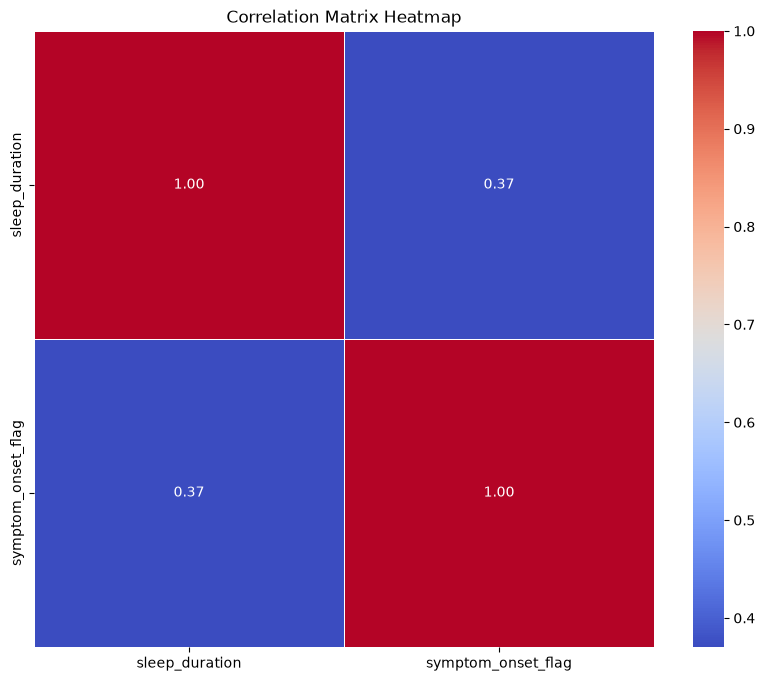

In [26]:
matrix_columns = ['sleep_duration', 'symptom_onset_flag']
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = df_sleep[matrix_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## Interpretation

After engineering the onset flag feature, there is a weak to moderate positive correlation between sleep_duration and the onset flag. This visualization indicates there could be a weak-moderate signal between the two.

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


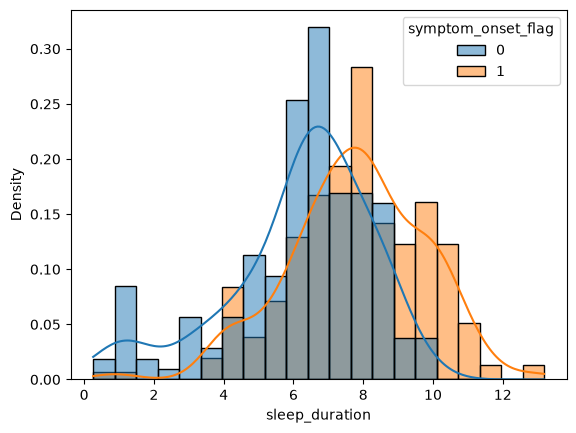

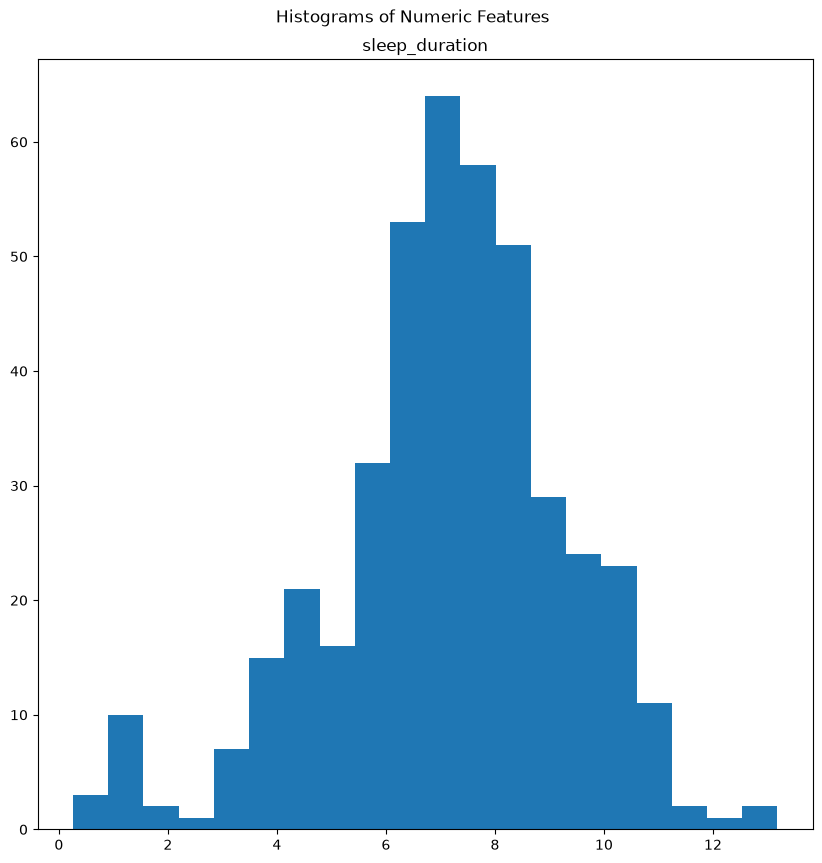

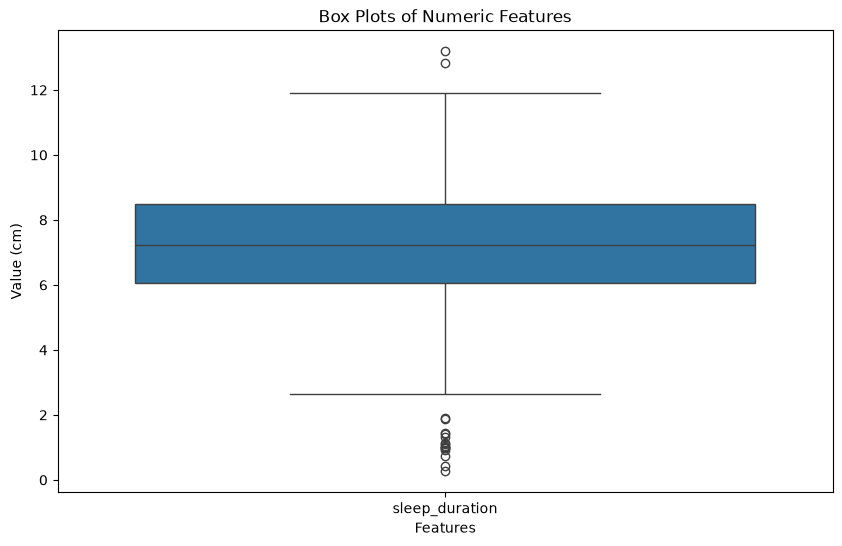

In [28]:
# Data Visualization
sns.histplot(data=df_sleep, x='sleep_duration', hue='symptom_onset_flag', 
             kde=True, stat='density', common_norm=False)

# Visualize distributions
df_sleep[numeric_columns].hist(bins=20, figsize=(10,10), grid=False)
plt.suptitle('Histograms of Numeric Features', y=0.93)
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sleep[numeric_columns])
plt.title('Box Plots of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Value (cm)')
plt.show()